# scRNA-seq Preprocessing and Clustering
Bone marrow mononuclear cells — NeurIPS 2021 benchmarking dataset.

## 0. Install dependencies
Run this cell first, then **Runtime → Restart session**, then run all cells again.

In [1]:
!pip install anndata scanpy pooch celltypist omnipath leidenalg -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 109.1 MB/s eta 0:00:00
ERROR: pip's dep

## 1. Imports

In [2]:
import anndata as ad
import pooch
import scanpy as sc

sc.set_figure_params(dpi=80, facecolor='white')
print('scanpy:', sc.__version__, '| anndata:', ad.__version__)


scanpy: 1.12.1 | anndata: 0.12.10


/tmp/ipykernel_13741/3398544438.py:6: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print('scanpy:', sc.__version__, '| anndata:', ad.__version__)
/tmp/ipykernel_13741/3398544438.py:6: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print('scanpy:', sc.__version__, '| anndata:', ad.__version__)


## 2. Download data

In [3]:
def download_sample(sample_id, known_hash):
    path = pooch.retrieve(
        path=pooch.os_cache('scverse_tutorials'),
        url=f'https://exampledata.scverse.org/tutorials/neurips-2021/{sample_id}_filtered_feature_bc_matrix.h5',
        known_hash=known_hash,
    )
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    return sample_adata

samples = {
    's1d1': 'md5:a99285913ea3f3d22600d3d2f8a88e34',
    's1d3': 'md5:825f7f7578e3dc0b8955f5a97a402338',
}
adatas = {id_: download_sample(id_, h) for id_, h in samples.items()}
adata = ad.concat(adatas, label='sample')
adata.obs_names_make_unique()
print(adata)


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## 3. Quality Control

In [4]:
adata.var['mt']   = adata.var_names.str.startswith('MT-')
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))
adata.var['hb']   = adata.var_names.str.contains('^HB[^(P)]')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo', 'hb'], inplace=True, log1p=True)


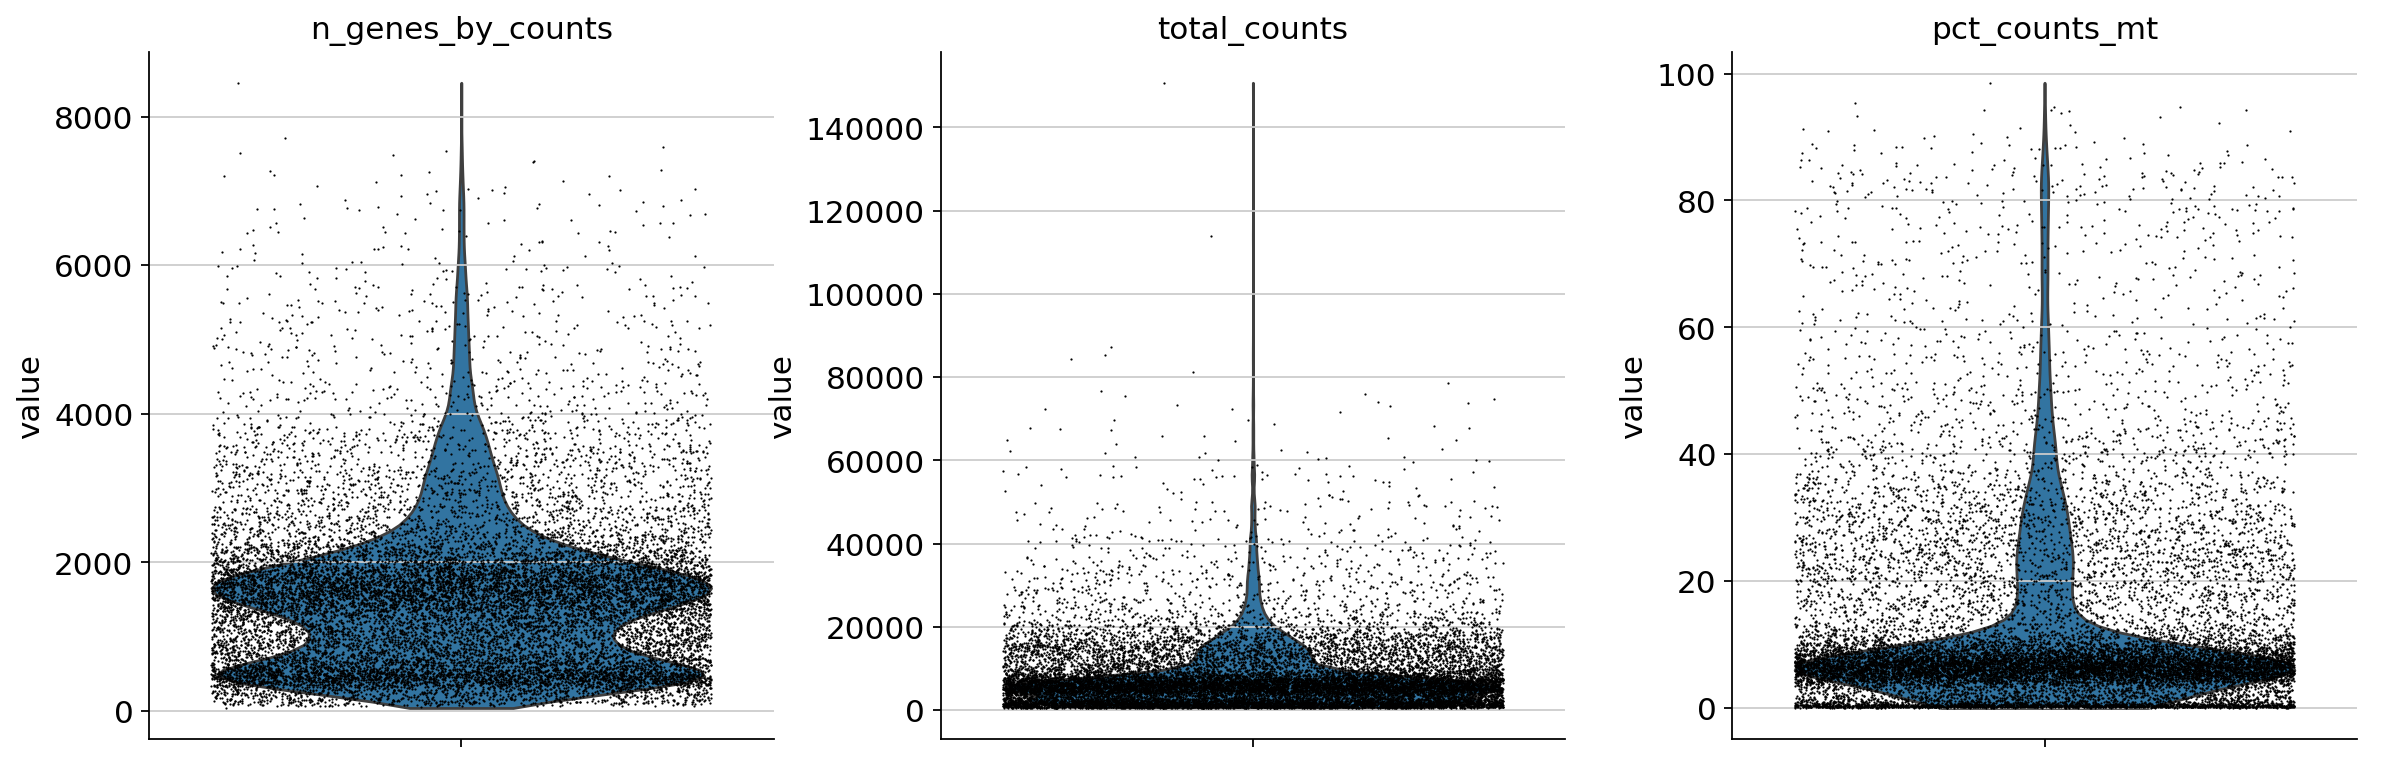

In [5]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4, multi_panel=True,
)


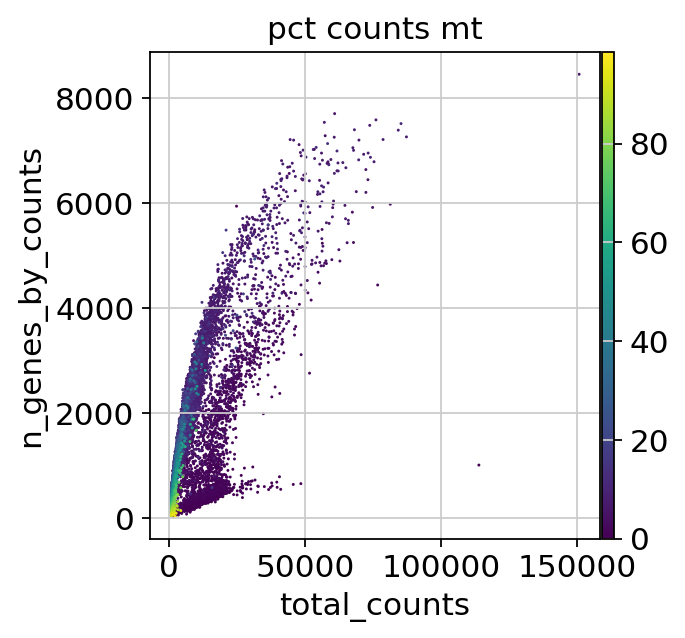

In [6]:
sc.pl.scatter(adata, 'total_counts', 'n_genes_by_counts', color='pct_counts_mt')


### 3.1 Filter low-quality cells and genes

In [7]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs['pct_counts_mt'] < 20].copy()
print('After filtering:', adata)


After filtering: AnnData object with n_obs × n_vars = 13670 × 23427
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'


### 3.2 Doublet detection with Scrublet
Scrublet flags likely doublets per sample batch.

In [8]:
sc.external.pp.scrublet(adata, batch_key='sample')


/tmp/ipykernel_13741/509609797.py:1: FutureWarning: Import from sc.pp instead
  sc.external.pp.scrublet(adata, batch_key='sample')


## 4. Normalization

In [9]:
adata.layers['counts'] = adata.X.copy()  # save raw counts
sc.pp.normalize_total(adata)              # normalize to median depth
sc.pp.log1p(adata)                        # log1p transform


## 5. Feature Selection — top 2000 highly variable genes

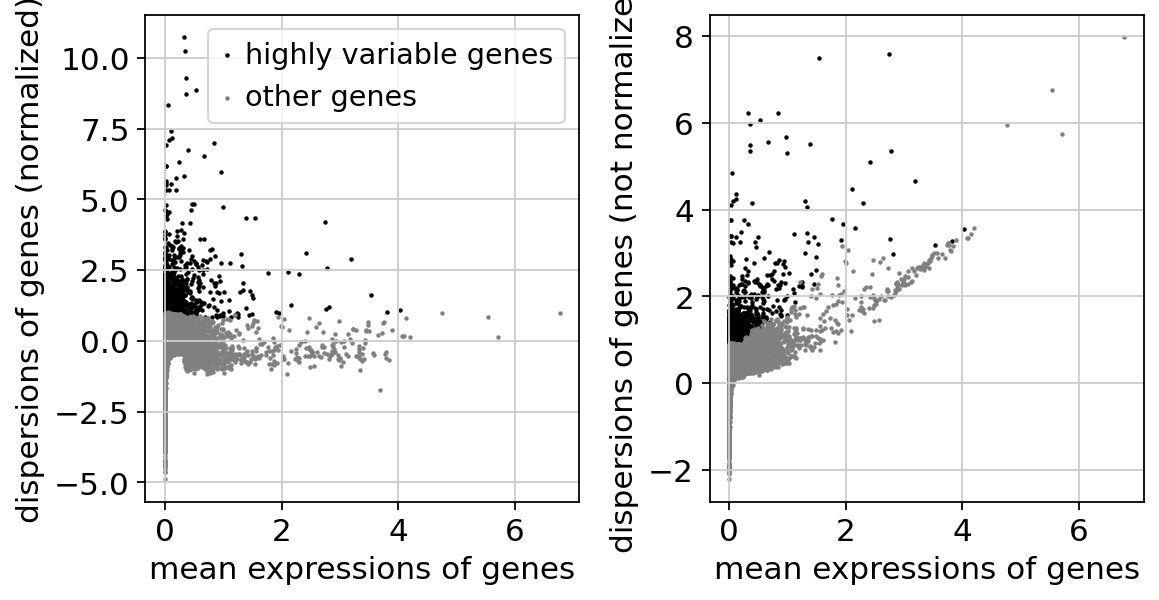

In [10]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key='sample')
sc.pl.highly_variable_genes(adata)


## 6. PCA

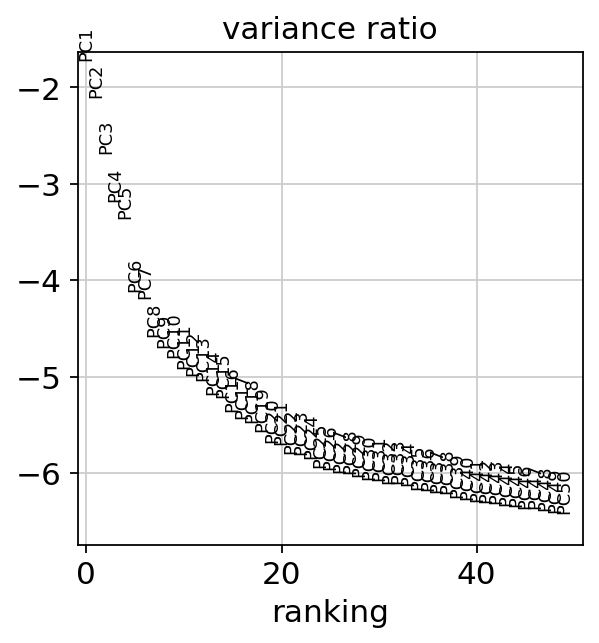

In [11]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)


## 7. Neighbors and UMAP

In [12]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)


## 8. Clustering (Leiden)

In [13]:
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_res0_5')
sc.tl.leiden(adata, resolution=1.0, key_added='leiden_res1_0')
sc.tl.leiden(adata, resolution=2.0, key_added='leiden_res2_0')


/tmp/ipykernel_13741/3148639186.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5, key_added='leiden_res0_5')
/tmp/ipykernel_13741/3148639186.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=1.0, key_added='

## 9. Visualize UMAP — sample, doublets, clusters
*UMAP is now computed so all plots below will work.*

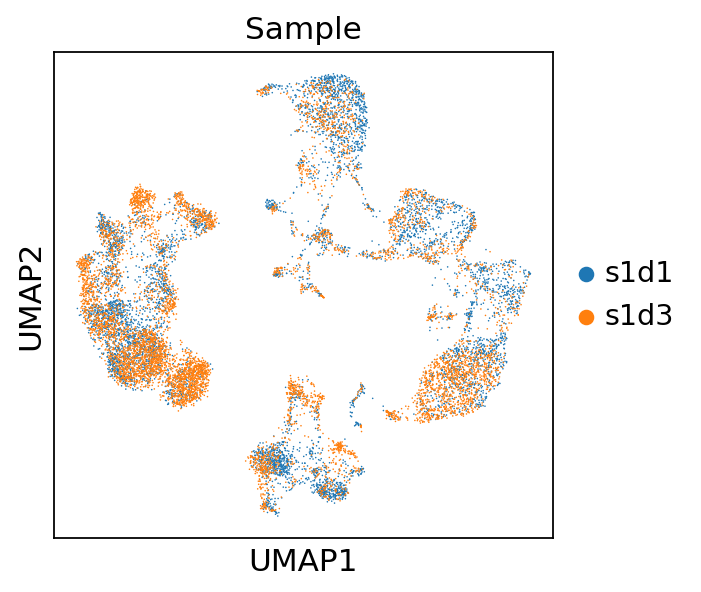

In [14]:
sc.pl.umap(adata, color='sample', size=2, title='Sample')


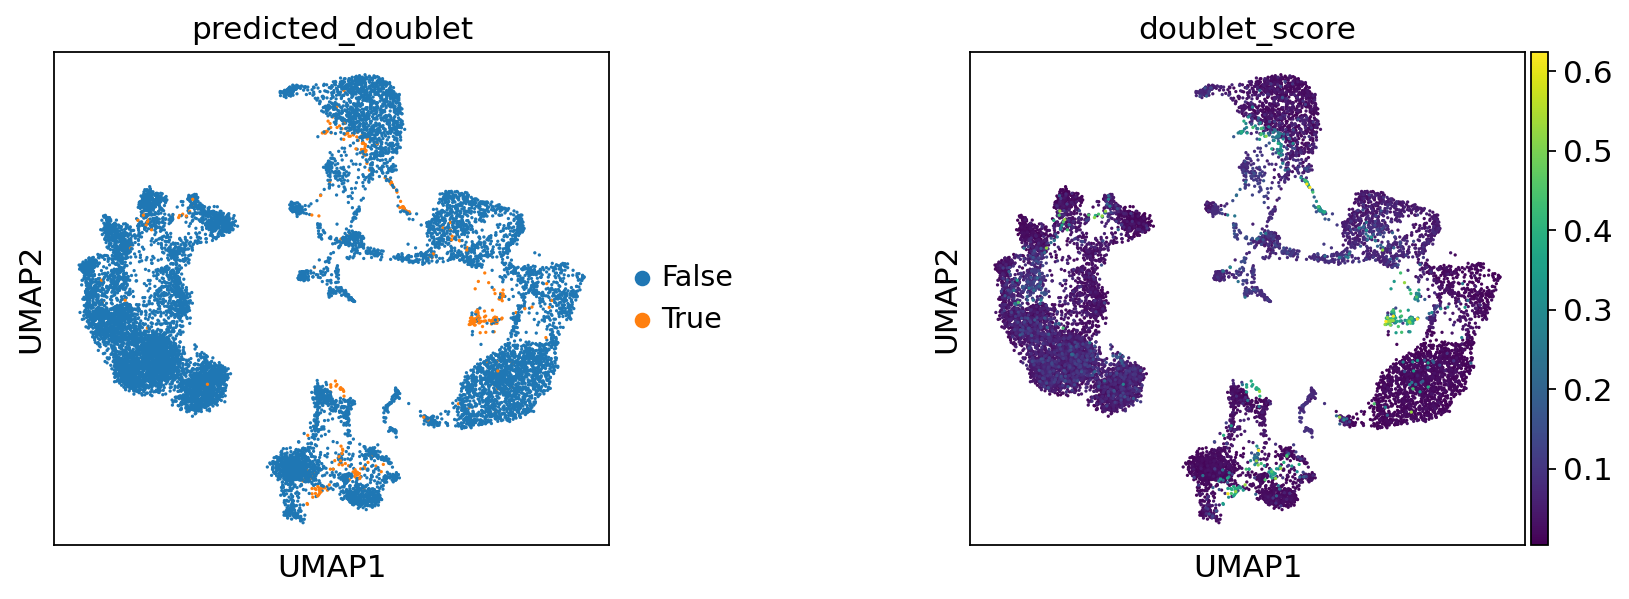

In [15]:
adata.obs['predicted_doublet'] = adata.obs['predicted_doublet'].astype('category')
sc.pl.umap(
    adata,
    color=['predicted_doublet', 'doublet_score'],
    wspace=0.5,
)


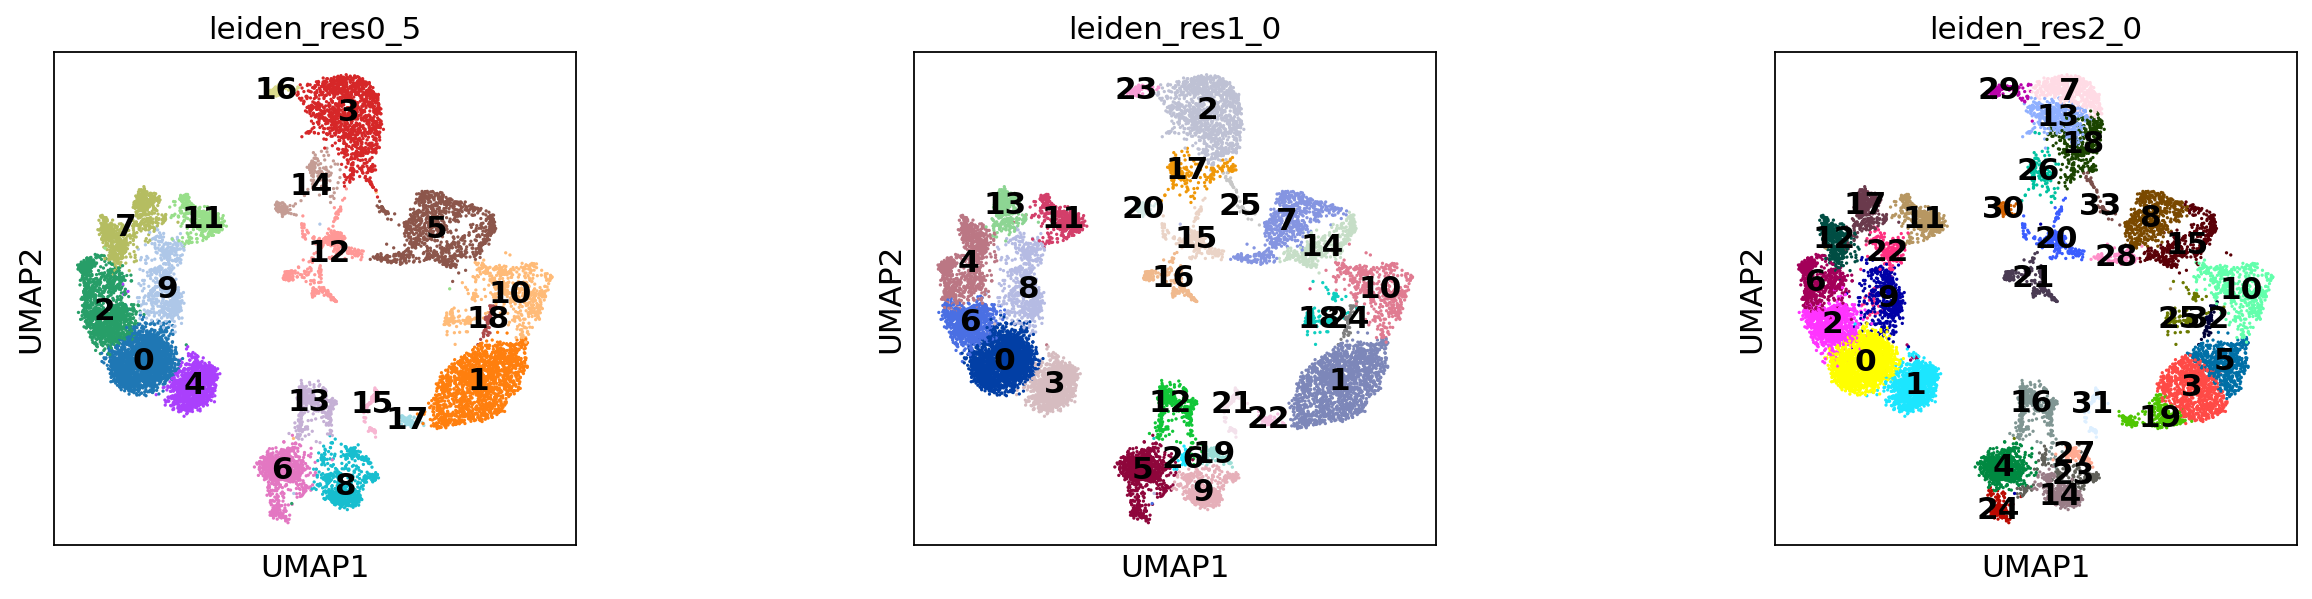

In [16]:
sc.pl.umap(
    adata,
    color=['leiden_res0_5', 'leiden_res1_0', 'leiden_res2_0'],
    legend_loc='on data',
    wspace=0.5,
)


## 10. Remove doublets

In [17]:
adata = adata[~adata.obs['predicted_doublet'].to_numpy()].copy()
print('Cells after doublet removal:', adata.n_obs)


Cells after doublet removal: 13347


## 11. Marker Gene Analysis

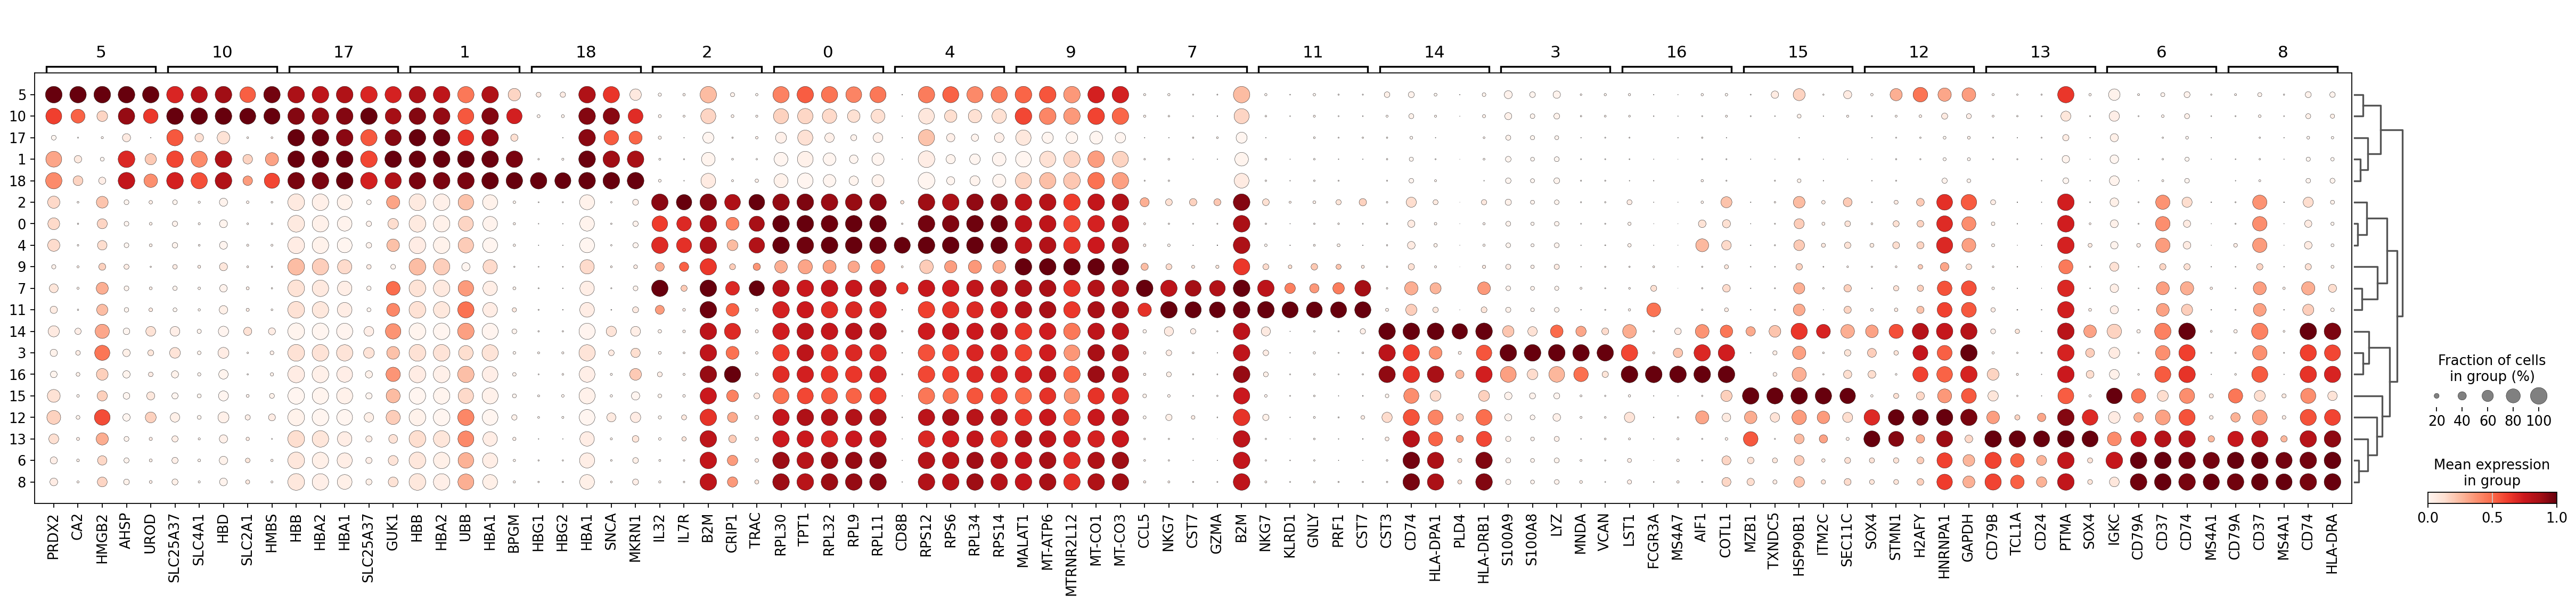

In [18]:
sc.tl.rank_genes_groups(adata, groupby='leiden_res0_5', method='wilcoxon')
sc.pl.rank_genes_groups_dotplot(
    adata, groupby='leiden_res0_5', standard_scale='var', n_genes=5,
)


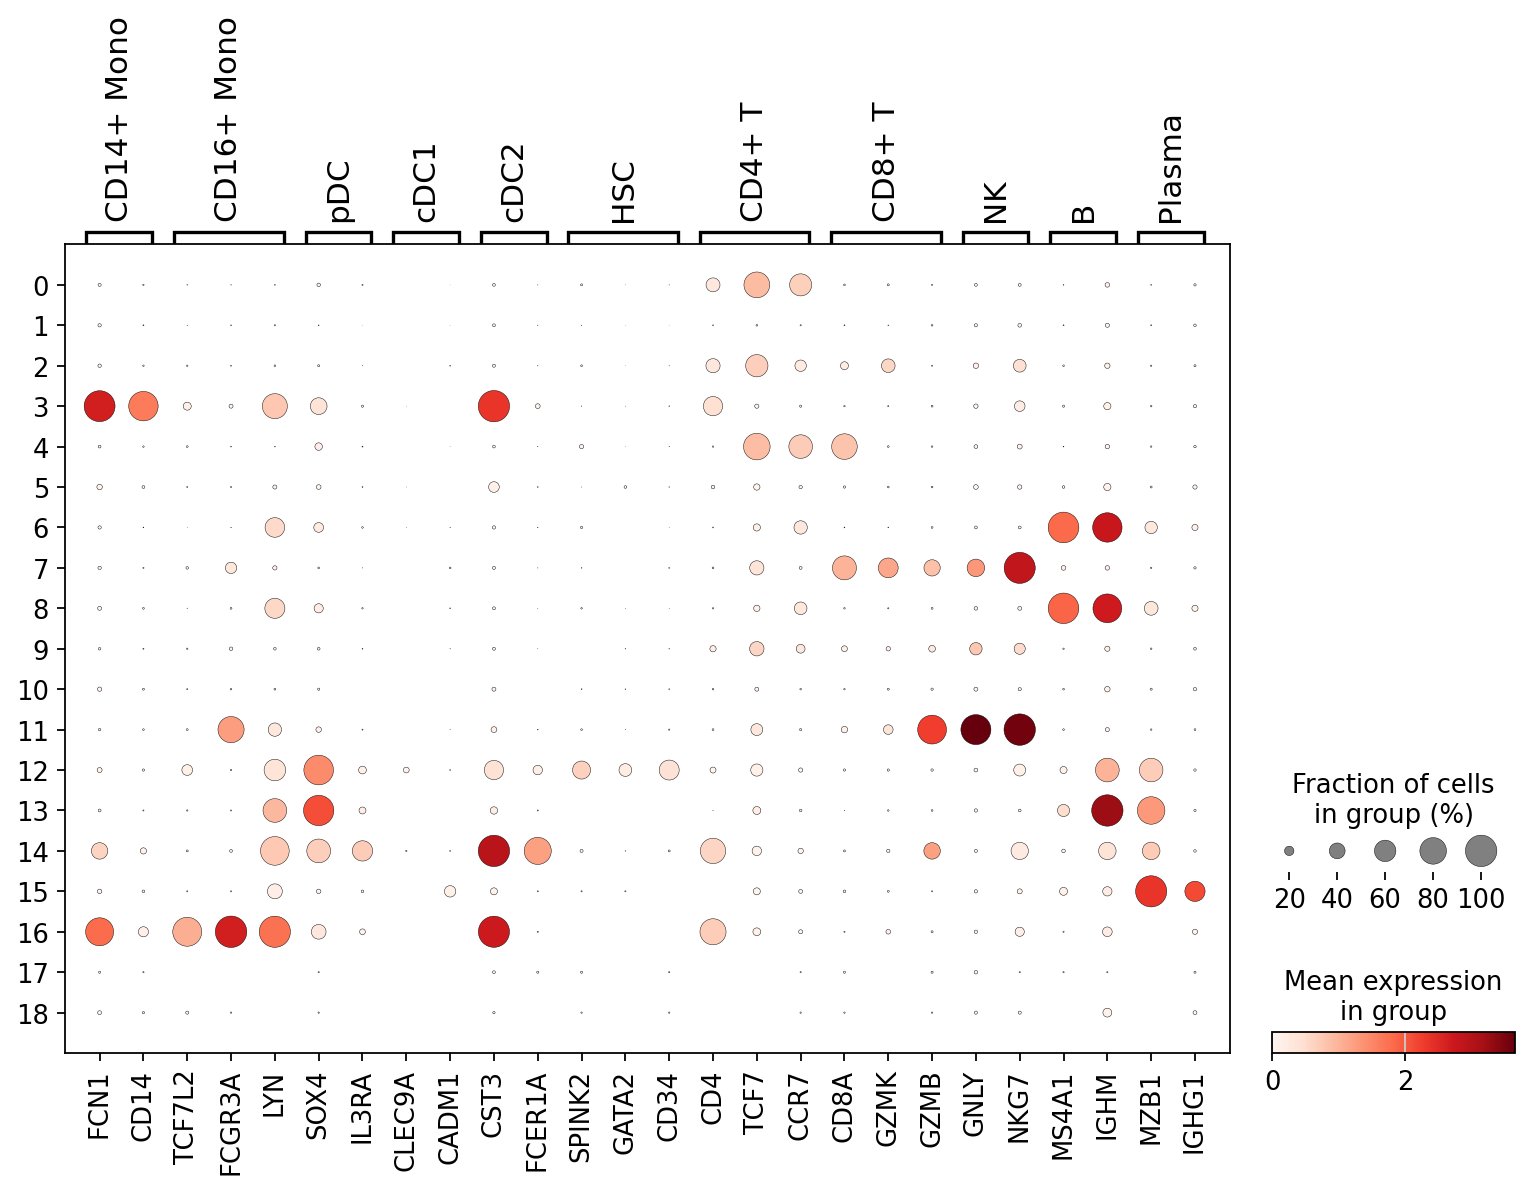

In [19]:
marker_genes = {
    'CD14+ Mono':  ['FCN1', 'CD14'],
    'CD16+ Mono':  ['TCF7L2', 'FCGR3A', 'LYN'],
    'pDC':         ['SOX4', 'IL3RA'],
    'cDC1':        ['CLEC9A', 'CADM1'],
    'cDC2':        ['CST3', 'FCER1A'],
    'HSC':         ['SPINK2', 'GATA2', 'CD34'],
    'CD4+ T':      ['CD4', 'TCF7', 'CCR7'],
    'CD8+ T':      ['CD8A', 'GZMK', 'GZMB'],
    'NK':          ['GNLY', 'NKG7'],
    'B':           ['MS4A1', 'IGHM'],
    'Plasma':      ['MZB1', 'IGHG1'],
}
sc.pl.dotplot(adata, marker_genes, groupby='leiden_res0_5')


## 12. Automatic Cell Type Annotation — CellTypist

In [20]:
import celltypist as ct
ct.models.download_models(model=['Immune_All_Low.pkl'], force_update=True)


/usr/local/lib/python3.12/dist-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [21]:
predictions = ct.annotate(
    adata,
    model='Immune_All_Low.pkl',
    majority_voting=True,
    over_clustering='leiden_res0_5',
)
adata = predictions.to_adata()


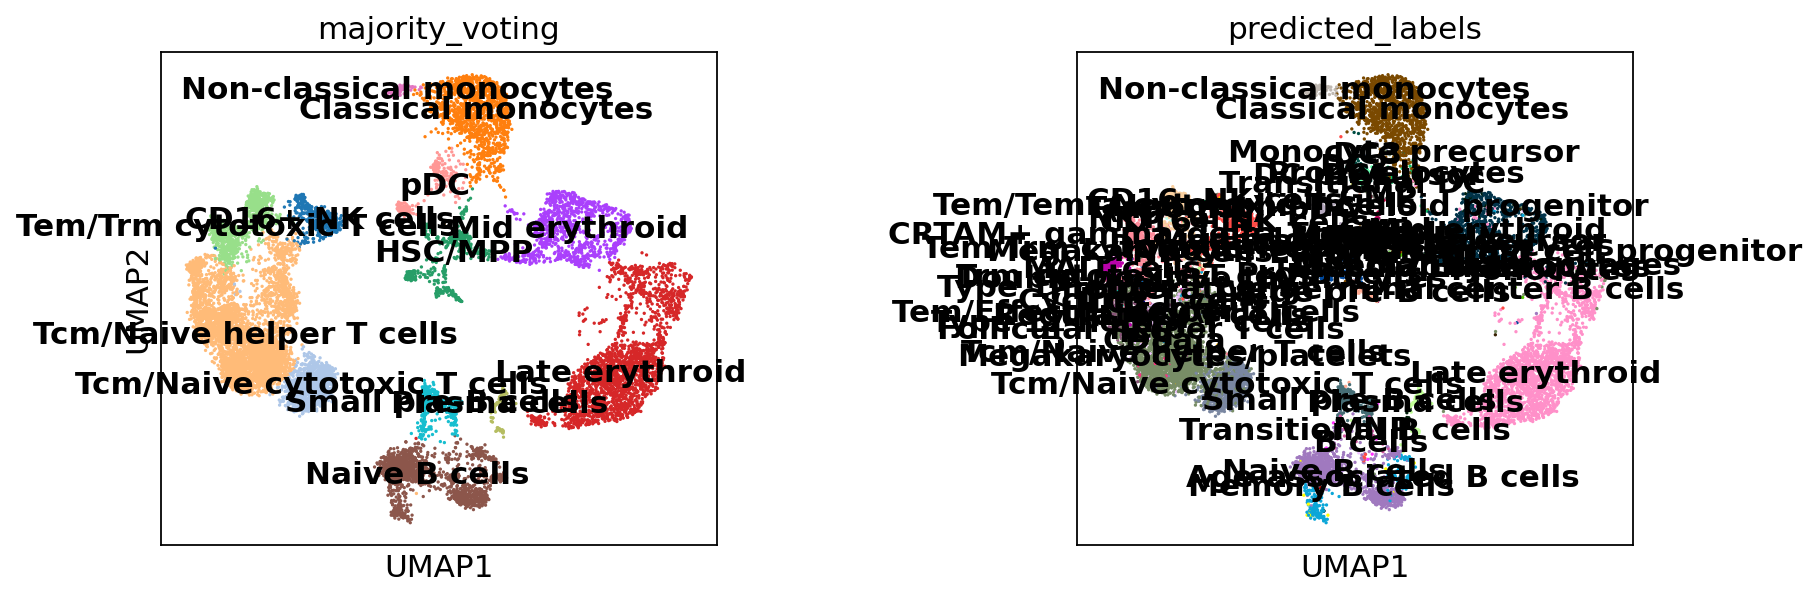

In [22]:
sc.pl.umap(
    adata,
    color=['majority_voting', 'predicted_labels'],
    wspace=0.5, legend_loc='on data',
)


## 13. OmniPath / PanglaoDB marker lookup

In [24]:
import pandas as pd
import omnipath as op
markers = op.requests.Annotations.get(resources='PanglaoDB')

# Extract cell type annotations
cell_type_annotations = markers[markers['label'] == 'cell_type'][['genesymbol', 'value']]
cell_type_annotations = cell_type_annotations.rename(columns={'value': 'cell_type'})

# Extract organ annotations
organ_annotations = markers[markers['label'] == 'organ'][['genesymbol', 'value']]
organ_annotations = organ_annotations.rename(columns={'value': 'organ'})

# Merge the annotations to get genesymbol, cell_type, and organ in a single DataFrame
merged_annotations = pd.merge(cell_type_annotations, organ_annotations, on='genesymbol', how='outer')

# Now filter based on the 'cell_type' column of the merged DataFrame
immune = merged_annotations[
    merged_annotations['cell_type'].str.contains('T cell|B cell|NK|Monocyte|Dendritic', case=False, na=False, regex=True)
]

print(immune[['genesymbol', 'cell_type', 'organ']].head(20))

    genesymbol          cell_type            organ
3       A3FIN4         Mast cells    Immune system
4       A4GALT         Mast cells    Immune system
32       ABCB4      B cells naive    Immune system
130        ACE          Monocytes             Bone
131        ACE          Monocytes      Vasculature
132        ACE          Monocytes    Immune system
134      ACER3         Mast cells    Immune system
147       ACHE         Mast cells  Skeletal muscle
148       ACHE         Mast cells    Immune system
149       ACHE         Mast cells    Immune system
150       ACHE         Mast cells            Brain
151       ACHE         Mast cells            Brain
152       ACHE         Mast cells             Skin
172      ACKR2  Trophoblast cells           Embryo
202       ACO2    Transient cells           Kidney
206       ACP5          Monocytes             Bone
207       ACP5          Monocytes    Immune system
208       ACP5          Monocytes    Immune system
355       ADA2          Monocyt

## 14. Save results

In [25]:
adata.write_h5ad('pbmc_processed.h5ad', compression='gzip')
print('Saved to pbmc_processed.h5ad')


Saved to pbmc_processed.h5ad
